# AI Forge – Week 1 Assignment
## ***Data Exploration, Feature Engineering & PCA***

In this assignment you will:

• **Load and explore** a dataset  
• **Perform** feature engineering  
• **Scale** numerical data  
• **Apply** PCA  
• **Interpret** the results  



**🔴 Make sure to Run all code cells from top to bottom before answering the questions:**

**Dataset:**
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams


In [16]:
!pip install pandas scikit-learn matplotlib

# part 01 - Load the Dataset

*  Import the necessary libraries
*  Load the dataset from the Kaggle link
*  Display the first 5 rows of the dataset
*  Print the shape of the dataset

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('StudentsPerformance.csv')

# Display first 5 rows and shape
print(df.head())
print("Dataset Shape:", df.shape)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Dataset Shape: (1000, 8)


# Part 2 – Feature Engineering

*   Analyze the existing features.
*   Create at least one new feature based on the existing columns
*   Add the new feature to the dataset.
*   Display the updated dataset

In [18]:
# Create a new feature: Average Score
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Display updated dataset
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   average_score  
0      72.666667  
1      82.333333  
2      92.666667  
3      49.333333  
4      76.333333  


# Part 3 – Scaling the Data


*   ÉImport a scaling technique from sklearn.preprocessing.
*   select numerical columns.
*   Apply scaling to these columns.
*   Display the scaled data.

***Comment***: Explain why scaling is important.



In [19]:
# resume 3la data
#select onlu numerical scaling
numerical_cols = ['math score', 'reading score', 'writing score']
#apply standard scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])
#display selected data
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols)
print(scaled_df.head())

   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333


*Write your comment here…*

# Part 4 – PCA

*   Import PCA from `sklearn.decomposition`
*   Apply PCA to the scaled dataset.
*   Reduce the dataset to 2 principal components.
*   Store the result in a new DataFrame.




In [20]:
# Import PCA
from sklearn.decomposition import PCA
# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)
# Store in new DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
# Display result
print(pca_df.head())

        PC1       PC2
0  0.560514  0.088285
1  1.719201 -0.910745
2  2.883135 -0.021999
3 -2.119921 -0.074994
4  0.988094  0.131914


#Part 5 - Visualize PCA Results


*   Import `matplotlib.pyplot`
*   Create a scatter plot using the two principal components.
*   Label the axes.
*   Observe how the data points are distributed.













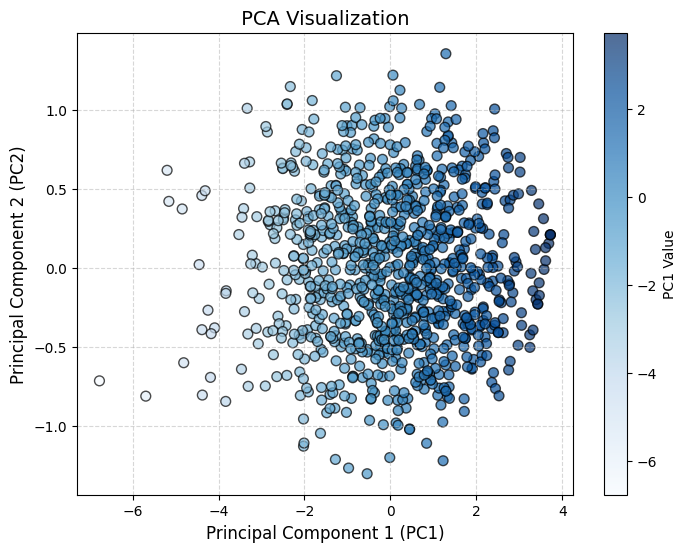

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['PC1'],
    cmap='Blues',
    s=50,
    alpha=0.7,
    edgecolor='black'
)

plt.colorbar(label='PC1 Value')

plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)

plt.title(' PCA Visualization ', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Part 5 – Reflection

Write a short reflection (5–8 sentences) answering:

*   What was the most challenging part of this assignment?
*   What did you learn about feature engineering?
*   Why is scaling important before applying PCA?
*   How can PCA help in machine learning projects?





*Write your reflection here…*